---
## Setup: Install Dependencies

In [1]:
!pip install torch numpy matplotlib

## Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import Counter

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


---
## Dataset

The dataset contains short sentences about AI and machine learning concepts. Both components share the same corpus.

In [3]:
corpus = [
    "artificial intelligence systems learn patterns from data.",
    "sequence models process information step by step.",
    "recurrent neural networks are useful for sequence prediction.",
    "lstm networks handle long term dependencies.",
    "deep learning models improve sequence learning.",
    "generative models create new samples from learned patterns.",
    "language models predict the next word in a sentence.",
    "sequence generation is used in chatbots and assistants.",
    "machine learning helps computers learn automatically.",
    "training data improves model accuracy.",
    "neural networks simulate human brain structures.",
    "optimization algorithms improve learning efficiency.",
    "technology is transforming modern education.",
    "online learning platforms use artificial intelligence.",
    "students benefit from intelligent tutoring systems.",
    "automation improves productivity and decision making.",
]

# Join all sentences into one text block
full_text = ' '.join(corpus)
print(f"Corpus size: {len(corpus)} sentences")
print(f"Total characters: {len(full_text)}")
print(f"\nFirst 3 sentences:")
for s in corpus[:3]:
    print(f"  → {s}")

Corpus size: 16 sentences
Total characters: 832

First 3 sentences:
  → artificial intelligence systems learn patterns from data.
  → sequence models process information step by step.
  → recurrent neural networks are useful for sequence prediction.


### Task 1 & 2: Preprocess Data – Character-Level Tokenization

In [4]:
# Build character vocabulary
chars = sorted(set(full_text))
vocab_size = len(chars)

char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {chars}")

# Encode the full text
encoded = [char2idx[ch] for ch in full_text]
print(f"\nEncoded length: {len(encoded)} tokens")
print(f"First 20 encoded values: {encoded[:20]}")

Vocabulary size: 27 unique characters
Characters: [' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Encoded length: 832 tokens
First 20 encoded values: [2, 18, 20, 10, 7, 10, 4, 10, 2, 12, 0, 10, 14, 20, 6, 12, 12, 10, 8, 6]


### Task 3: Create Input-Output Sequence Pairs

In [5]:
SEQ_LEN = 30  # Number of characters per input sequence

def create_sequences(encoded_text, seq_len):
    """Create sliding window (input, target) pairs."""
    inputs, targets = [], []
    for i in range(len(encoded_text) - seq_len):
        inputs.append(encoded_text[i : i + seq_len])
        targets.append(encoded_text[i + 1 : i + seq_len + 1])  # shifted by 1
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

X, Y = create_sequences(encoded, SEQ_LEN)
print(f"Input shape:  {X.shape}  (sequences × seq_len)")
print(f"Target shape: {Y.shape}")
print(f"\nExample input sequence: {''.join(idx2char[i.item()] for i in X[0])}")
print(f"Example target sequence: {''.join(idx2char[i.item()] for i in Y[0])}")

Input shape:  torch.Size([802, 30])  (sequences × seq_len)
Target shape: torch.Size([802, 30])

Example input sequence: artificial intelligence system
Example target sequence: rtificial intelligence systems


### Task 4: Design the LSTM Model

In [6]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM language model.
    Architecture: Embedding → LSTM → Linear → Logits
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super(CharLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)              # (batch, seq, embed_dim)
        out, hidden = self.lstm(emb, hidden) # (batch, seq, hidden_dim)
        out = self.dropout(out)
        logits = self.fc(out)                # (batch, seq, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        return (h0, c0)


# Instantiate the model
lstm_model = CharLSTM(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3
).to(device)

print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

CharLSTM(
  (embedding): Embedding(27, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=27, bias=True)
)

Total trainable parameters: 236,635


### Task 5: Train the LSTM Model

In [7]:
from torch.utils.data import DataLoader, TensorDataset

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 60
LR = 0.003

# DataLoader
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=LR)

train_losses = []

lstm_model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()

        logits, _ = lstm_model(xb)
        # Reshape: (batch * seq_len, vocab_size) vs (batch * seq_len,)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch  10/60 | Loss: 0.3020
Epoch  20/60 | Loss: 0.2074
Epoch  30/60 | Loss: 0.1835
Epoch  40/60 | Loss: 0.1715
Epoch  50/60 | Loss: 0.1712
Epoch  60/60 | Loss: 0.1665

Training complete!


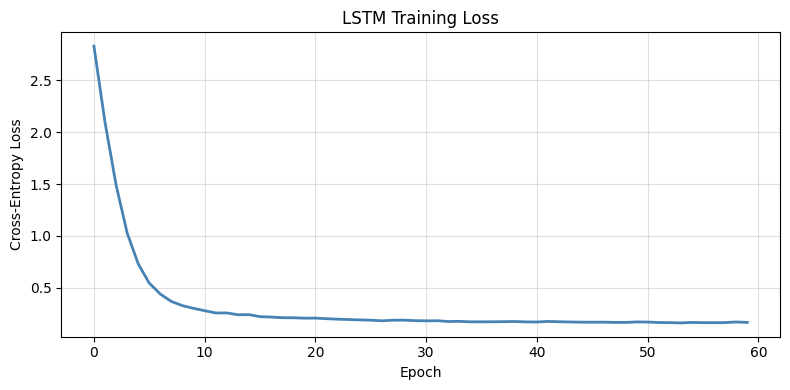

In [8]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('LSTM Training Loss')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Task 6: Generate New Sequences Using a Seed Input

The **temperature** parameter controls randomness:
- `temperature < 1.0` → more conservative/predictable output
- `temperature > 1.0` → more creative/random output

In [9]:
def generate_lstm(model, seed_text, gen_length=100, temperature=0.8):
    """
    Generate text character by character starting from seed_text.
    """
    model.eval()
    with torch.no_grad():
        # Encode seed
        seed_encoded = [char2idx.get(ch, 0) for ch in seed_text]
        input_tensor = torch.tensor([seed_encoded], dtype=torch.long).to(device)
        hidden = model.init_hidden(1, device)

        # Warm up on the seed
        _, hidden = model(input_tensor, hidden)

        generated = list(seed_text)
        # Feed the last character and generate one by one
        next_input = torch.tensor([[seed_encoded[-1]]], dtype=torch.long).to(device)

        for _ in range(gen_length):
            logits, hidden = model(next_input, hidden)
            # Apply temperature
            probs = torch.softmax(logits[0, 0] / temperature, dim=0)
            next_idx = torch.multinomial(probs, 1).item()
            generated.append(idx2char[next_idx])
            next_input = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return ''.join(generated)


# --- Expected Output: Generated text sequences ---
print("=" * 60)
print("EXPECTED OUTPUT: Generated Text Sequences (LSTM)")
print("=" * 60)

seeds = ["artificial", "neural", "sequence"]
for seed in seeds:
    print(f"\nSeed: '{seed}'")
    for temp in [0.5, 0.8, 1.2]:
        result = generate_lstm(lstm_model, seed, gen_length=80, temperature=temp)
        print(f"  [temp={temp}] {result}")

EXPECTED OUTPUT: Generated Text Sequences (LSTM)

Seed: 'artificial'
  [temp=0.5] artificial intelligence. students benefit from intelligent tutoring systems. automation im
  [temp=0.8] artificial intelligence. students benefit from intelligent tutoring systems. automation im
  [temp=1.2] artificial intelligence systems learn patterns from data. sequence models process informat

Seed: 'neural'
  [temp=0.5] neural networks simulate human brain structures. optimization algorithms improve learn
  [temp=0.8] neural networks simulate human brain structures. optimization algorithms improve learn
  [temp=1.2] neural networks simulate human brain structures. optimization algorithms improve learn

Seed: 'sequence'
  [temp=0.5] sequence models process information step by step. recurrent neural networks are useful f
  [temp=0.8] sequence models process information step by step. recurrent neural networks are useful f
  [temp=1.2] sequence learning. generative models create new samples from learned

---
# Component II: Transformer-Based Sequential Data Generation

### Tasks
1. Use the same dataset as Component I
2. Apply word-level tokenization
3. Implement positional encoding for sequence order
4. Design a Transformer encoder architecture
5. Train the model for sequence generation

### Task 1 & 2: Word-Level Tokenization

In [10]:
import re

# Tokenize at word level (lowercase, keep punctuation as separate tokens)
def word_tokenize(text):
    return re.findall(r"[a-z]+|[^\s]", text.lower())

word_tokens = word_tokenize(full_text)

# Build vocabulary with special tokens
word_counts = Counter(word_tokens)
vocab = ['<PAD>', '<UNK>'] + sorted(word_counts.keys())
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
word_vocab_size = len(vocab)

encoded_words = [w2i.get(t, w2i['<UNK>']) for t in word_tokens]

print(f"Word vocabulary size: {word_vocab_size}")
print(f"Total word tokens: {len(encoded_words)}")
print(f"Vocabulary: {vocab}")

Word vocabulary size: 80
Total word tokens: 120
Vocabulary: ['<PAD>', '<UNK>', '.', 'a', 'accuracy', 'algorithms', 'and', 'are', 'artificial', 'assistants', 'automatically', 'automation', 'benefit', 'brain', 'by', 'chatbots', 'computers', 'create', 'data', 'decision', 'deep', 'dependencies', 'education', 'efficiency', 'for', 'from', 'generation', 'generative', 'handle', 'helps', 'human', 'improve', 'improves', 'in', 'information', 'intelligence', 'intelligent', 'is', 'language', 'learn', 'learned', 'learning', 'long', 'lstm', 'machine', 'making', 'model', 'models', 'modern', 'networks', 'neural', 'new', 'next', 'online', 'optimization', 'patterns', 'platforms', 'predict', 'prediction', 'process', 'productivity', 'recurrent', 'samples', 'sentence', 'sequence', 'simulate', 'step', 'structures', 'students', 'systems', 'technology', 'term', 'the', 'training', 'transforming', 'tutoring', 'use', 'used', 'useful', 'word']


In [11]:
# Create word-level sequence pairs
WORD_SEQ_LEN = 8

Xw, Yw = create_sequences(encoded_words, WORD_SEQ_LEN)
print(f"Word-level input shape:  {Xw.shape}")
print(f"Word-level target shape: {Yw.shape}")

ex_in  = ' '.join(i2w[i.item()] for i in Xw[0])
ex_out = ' '.join(i2w[i.item()] for i in Yw[0])
print(f"\nExample input:  {ex_in}")
print(f"Example target: {ex_out}")

Word-level input shape:  torch.Size([112, 8])
Word-level target shape: torch.Size([112, 8])

Example input:  artificial intelligence systems learn patterns from data .
Example target: intelligence systems learn patterns from data . sequence


### Task 3: Positional Encoding

Transformers have no inherent sense of order, so we add **sinusoidal positional encodings** to the embeddings.

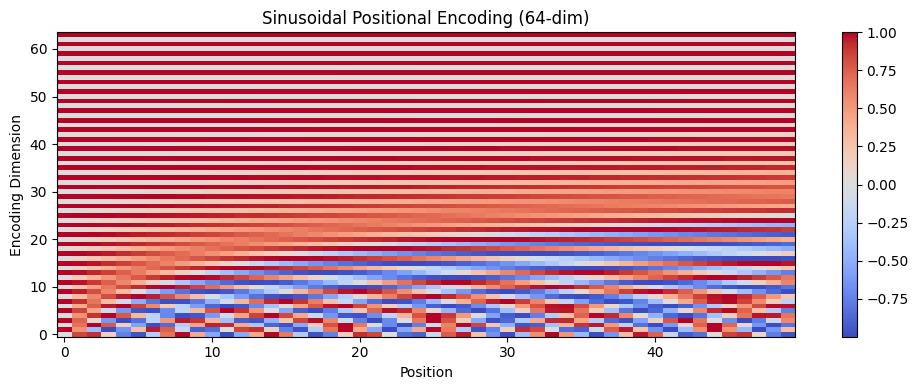

In [12]:
class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to input embeddings.
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)  # even dims
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Visualize positional encodings
pe_viz = PositionalEncoding(d_model=64, max_len=50)
pe_matrix = pe_viz.pe[0].detach().numpy()

plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix.T, aspect='auto', cmap='coolwarm', origin='lower')
plt.colorbar()
plt.xlabel('Position')
plt.ylabel('Encoding Dimension')
plt.title('Sinusoidal Positional Encoding (64-dim)')
plt.tight_layout()
plt.show()

### Task 4: Design the Transformer Model

We use a **causal (autoregressive) Transformer decoder** — each position can only attend to previous positions via a causal mask.

In [13]:
class TransformerLM(nn.Module):
    """
    Autoregressive Transformer Language Model.
    Architecture: Embedding + PositionalEncoding → TransformerEncoder (causal) → Linear
    """
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, max_seq_len=512):
        super().__init__()
        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_seq_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def _causal_mask(self, seq_len, device):
        """Upper-triangular mask to prevent attending to future positions."""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
        return mask  # True = masked (ignored)

    def forward(self, x):
        seq_len = x.size(1)
        causal_mask = self._causal_mask(seq_len, x.device)

        emb = self.embedding(x) * math.sqrt(self.d_model)  # scale embeddings
        emb = self.pos_encoding(emb)

        out = self.transformer(emb, mask=causal_mask, is_causal=True)
        logits = self.fc_out(out)  # (batch, seq_len, vocab_size)
        return logits


# Instantiate model
transformer_model = TransformerLM(
    vocab_size=word_vocab_size,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_seq_len=512
).to(device)

print(transformer_model)
total_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

TransformerLM(
  (embedding): Embedding(80, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=64, out_features=80, bias=True)
)

Total trainable parameters: 77,264


### Task 5: Train the Transformer Model

In [14]:
BATCH_SIZE_T = 16
EPOCHS_T = 80
LR_T = 0.001

dataset_t = TensorDataset(Xw, Yw)
loader_t = DataLoader(dataset_t, batch_size=BATCH_SIZE_T, shuffle=True)

criterion_t = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD
optimizer_t = optim.Adam(transformer_model.parameters(), lr=LR_T)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=EPOCHS_T)

train_losses_t = []

transformer_model.train()
for epoch in range(1, EPOCHS_T + 1):
    epoch_loss = 0
    for xb, yb in loader_t:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_t.zero_grad()

        logits = transformer_model(xb)  # (batch, seq, vocab)
        loss = criterion_t(logits.view(-1, word_vocab_size), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer_t.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(loader_t)
    train_losses_t.append(avg_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS_T} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")

print("\nTraining complete!")

Epoch  20/80 | Loss: 0.4736 | LR: 0.00085
Epoch  40/80 | Loss: 0.2014 | LR: 0.00050
Epoch  60/80 | Loss: 0.1661 | LR: 0.00015
Epoch  80/80 | Loss: 0.1519 | LR: 0.00000

Training complete!


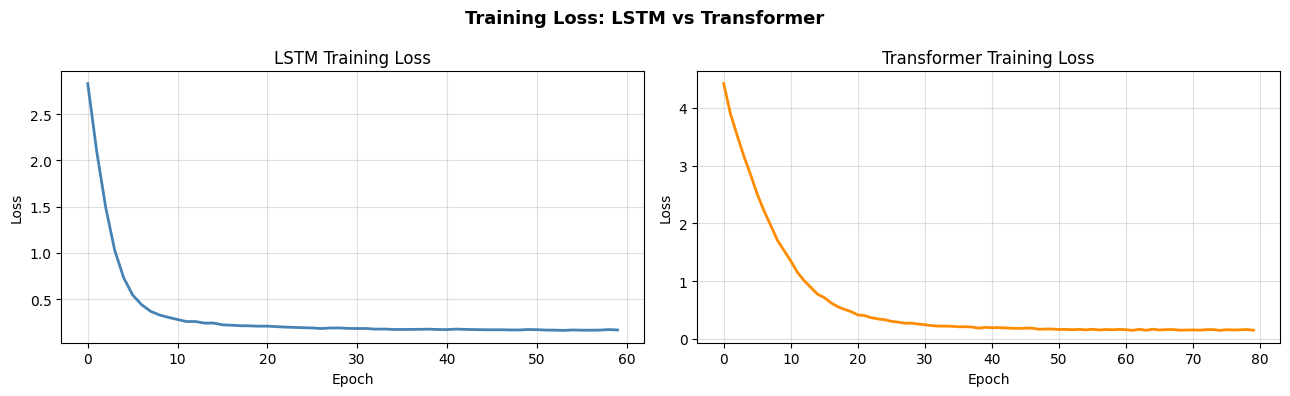

In [15]:
# Plot training loss comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, color='steelblue', linewidth=2)
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.4)

axes[1].plot(train_losses_t, color='darkorange', linewidth=2)
axes[1].set_title('Transformer Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Loss: LSTM vs Transformer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Generate Sequences from the Transformer Model

In [16]:
def generate_transformer(model, seed_words, gen_length=15, temperature=0.8):
    """
    Generate word-level sequences using the Transformer model.
    """
    model.eval()
    with torch.no_grad():
        seed_encoded = [w2i.get(w, w2i['<UNK>']) for w in seed_words]
        generated_ids = list(seed_encoded)

        for _ in range(gen_length):
            inp = torch.tensor([generated_ids], dtype=torch.long).to(device)
            logits = model(inp)              # (1, seq_len, vocab_size)
            last_logits = logits[0, -1, :]   # logits for next token
            probs = torch.softmax(last_logits / temperature, dim=0)
            next_id = torch.multinomial(probs, 1).item()
            generated_ids.append(next_id)

    return ' '.join(i2w[i] for i in generated_ids)


# --- Expected Output: Generated sequences from the Transformer model ---
print("=" * 60)
print("EXPECTED OUTPUT: Generated Sequences (Transformer)")
print("=" * 60)

word_seeds = [
    ["neural", "networks"],
    ["sequence", "models"],
    ["deep", "learning"],
]

for seed in word_seeds:
    print(f"\nSeed: {seed}")
    for temp in [0.7, 1.0]:
        result = generate_transformer(transformer_model, seed, gen_length=12, temperature=temp)
        print(f"  [temp={temp}] {result}")

EXPECTED OUTPUT: Generated Sequences (Transformer)

Seed: ['neural', 'networks']
  [temp=0.7] neural networks are useful for sequence prediction . lstm networks handle long term dependencies
  [temp=1.0] neural networks are useful for sequence prediction . lstm networks handle long term dependencies

Seed: ['sequence', 'models']
  [temp=0.7] sequence models process information step by step . recurrent neural networks are useful for
  [temp=1.0] sequence models process information step by step . recurrent neural networks are helps computers

Seed: ['deep', 'learning']
  [temp=0.7] deep learning models improve sequence learning . generative models create new samples from learned
  [temp=1.0] deep learning models improve sequence learning . generative models create new samples from learned


---
## Comparison: LSTM vs Transformer

| Feature | LSTM | Transformer |
|---|---|---|
| Granularity | Character-level | Word-level |
| Memory | Sequential hidden state | Self-attention (all tokens) |
| Parallelism | Sequential (slow to train) | Fully parallel |
| Long-range deps | Limited | Strong (via attention) |
| Positional info | Implicit in state | Explicit (positional encoding) |
| Typical use | Moderate sequences | Long documents, LLMs |

In [17]:
print("=" * 65)
print("SIDE-BY-SIDE GENERATION COMPARISON")
print("=" * 65)

print("\n[LSTM – Character Level]")
for seed in ["neural", "sequence", "deep"]:
    result = generate_lstm(lstm_model, seed, gen_length=60, temperature=0.8)
    print(f"  seed='{seed}': {result}")

print("\n[Transformer – Word Level]")
for seed in [["neural", "networks"], ["sequence", "models"], ["deep", "learning"]]:
    result = generate_transformer(transformer_model, seed, gen_length=10, temperature=0.8)
    print(f"  seed={seed}: {result}")

SIDE-BY-SIDE GENERATION COMPARISON

[LSTM – Character Level]
  seed='neural': neural networks are useful for sequence prediction. lstm networks 
  seed='sequence': sequence models process information step by step. recurrent neural n
  seed='deep': deep learning models improve sequence learning. generative model

[Transformer – Word Level]
  seed=['neural', 'networks']: neural networks simulate human brain structures . optimization algorithms improve learning efficiency
  seed=['sequence', 'models']: sequence models process information step by step . recurrent neural networks simulate
  seed=['deep', 'learning']: deep learning models improve sequence learning . generative models improve sequence learning


---
## Summary

In this lab, you implemented two approaches to sequential data generation:

**Component I – LSTM:**
- Used character-level tokenization (finer granularity)
- LSTM captures sequential patterns through hidden state propagation
- Generated text character by character using temperature sampling

**Component II – Transformer:**
- Used word-level tokenization (semantic granularity)
- Positional encoding provides order information to the attention layers
- Causal (autoregressive) masking ensures the model only attends to past tokens
- Generated text word by word

**Key Takeaways:**
- Temperature controls the trade-off between creativity and coherence
- Both models learn to generate domain-relevant text from a small corpus
- Transformers generally scale better and handle long-range dependencies more effectively than LSTMs